# Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/amazon.csv")

In [3]:
cleaned_df=df.copy()

In [4]:
cleaned_df.shape

(1465, 16)

In [5]:
cleaned_df.dtypes

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

In [10]:
cleaned_df['discounted_price'].head()

0    ₹399
1    ₹199
2    ₹199
3    ₹329
4    ₹154
Name: discounted_price, dtype: str

In [11]:
cleaned_df['actual_price'].head()

0    ₹1,099
1      ₹349
2    ₹1,899
3      ₹699
4      ₹399
Name: actual_price, dtype: str

In [12]:
cleaned_df['discounted_price'] = (
    cleaned_df['discounted_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

In [13]:
cleaned_df['discounted_price'] = pd.to_numeric(
    cleaned_df['discounted_price'],
    errors='coerce'
)

In [14]:
cleaned_df['discounted_price'].head()

0    399.0
1    199.0
2    199.0
3    329.0
4    154.0
Name: discounted_price, dtype: float64

In [15]:
cleaned_df['discounted_price'].dtype

dtype('float64')

In [16]:
cleaned_df['actual_price'] = (
    cleaned_df['actual_price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
)

In [17]:
cleaned_df['actual_price']= pd.to_numeric(
  cleaned_df['actual_price'],
  errors='coerce'
)

In [18]:
cleaned_df['actual_price'].head()

0    1099.0
1     349.0
2    1899.0
3     699.0
4     399.0
Name: actual_price, dtype: float64

In [19]:
cleaned_df['actual_price'].dtype

dtype('float64')

In [20]:
cleaned_df['discount_percentage'].head()

0    64%
1    43%
2    90%
3    53%
4    61%
Name: discount_percentage, dtype: str

In [21]:
cleaned_df['discount_percentage'] = (
    cleaned_df['discount_percentage']
    .str.replace('%', '', regex=False)
)

In [22]:
cleaned_df['discount_percentage'] = pd.to_numeric(
    cleaned_df['discount_percentage'],
    errors='coerce'
)

In [23]:
cleaned_df['discount_percentage'].head()

0    64
1    43
2    90
3    53
4    61
Name: discount_percentage, dtype: int64

In [24]:
cleaned_df['discount_percentage'].dtype

dtype('int64')

In [25]:
cleaned_df['rating'].unique()

<StringArray>
['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3', '3.6', '3.4',
 '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0', '2.8',   '4', '3.1', '4.8',
 '2.3',   '|',   '2',   '3', '2.6', '2.9']
Length: 28, dtype: str

In [26]:
cleaned_df['rating'] = pd.to_numeric(
    cleaned_df['rating'],
    errors='coerce'
)

In [27]:
cleaned_df['rating'].dtype

dtype('float64')

In [30]:
cleaned_df['rating'].isnull().sum()

np.int64(1)

In [31]:
cleaned_df['rating'].mean()

np.float64(4.096584699453552)

In [32]:
cleaned_df['rating_count'].head()

0    24,269
1    43,994
2     7,928
3    94,363
4    16,905
Name: rating_count, dtype: str

In [33]:
cleaned_df['rating_count'] = (
    cleaned_df['rating_count']
    .astype(str)
    .str.replace(',', '', regex=False)
)

In [34]:
cleaned_df['rating_count'] = pd.to_numeric(
    cleaned_df['rating_count'],
    errors='coerce'
)

In [35]:
cleaned_df['rating_count'].isnull().sum()

np.int64(2)

In [41]:
cleaned_df['rating_count'] = cleaned_df['rating_count'].fillna(
    cleaned_df['rating_count'].median()
)

In [42]:
cleaned_df['rating_count'].isnull().sum()

np.int64(0)

In [43]:
cleaned_df['rating'] = cleaned_df['rating'].fillna(
    cleaned_df['rating'].median()
)

In [44]:
cleaned_df['rating'].isnull().sum()

np.int64(0)

In [45]:
cleaned_df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

# Feature Engineering

In [46]:
# discount amt=actual_price - discounted_price
cleaned_df['discount_amount'] = (
    cleaned_df['actual_price']
    -
    cleaned_df['discounted_price']
)

In [47]:
cleaned_df[
    ['actual_price',
     'discounted_price',
     'discount_amount']
].head()

,actual_price,discounted_price,discount_amount
0,1099.0,399.0,700.0
1,349.0,199.0,150.0
2,1899.0,199.0,1700.0
3,699.0,329.0,370.0
4,399.0,154.0,245.0


In [48]:
#discount ratio=discount_amount / actual_price
cleaned_df['discount_ratio'] = (
    cleaned_df['discount_amount']
    /
    cleaned_df['actual_price']
)

In [49]:
cleaned_df[
    ['discount_amount',
     'actual_price',
     'discount_ratio']
].head()

,discount_amount,actual_price,discount_ratio
0,700.0,1099.0,0.636943
1,150.0,349.0,0.429799
2,1700.0,1899.0,0.895208
3,370.0,699.0,0.529328
4,245.0,399.0,0.614035


In [51]:
# Popularity Score
cleaned_df['popularity_score'] = (
    cleaned_df['rating']
    *
    np.log1p(cleaned_df['rating_count'])
)

In [52]:
cleaned_df[
    ['rating',
     'rating_count',
     'popularity_score']
].head()

,rating,rating_count,popularity_score
0,4.2,24269.0,42.407384
1,4.0,43994.0,42.767325
2,3.9,7928.0,35.015301
3,4.2,94363.0,48.110643
4,4.2,16905.0,40.888780


In [53]:
cleaned_df.sort_values(
    by='popularity_score',
    ascending=False
)[
 ['product_name',
  'rating',
  'rating_count',
  'popularity_score']
].head(10)

,product_name,rating,rating_count,popularity_score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",4.4,426973.0,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",4.4,426973.0,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426973.0,57.043705
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,426972.0,57.043695
864,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,4.5,205052.0,55.039607
588,SanDisk Cruzer Blade 32GB USB Flash Drive,4.3,253105.0,53.498724
400,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
352,boAt Bassheads 100 in Ear Wired Earphones with...,4.1,363713.0,52.496905
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,4.1,363711.0,52.496882
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8,53803.0,52.286895


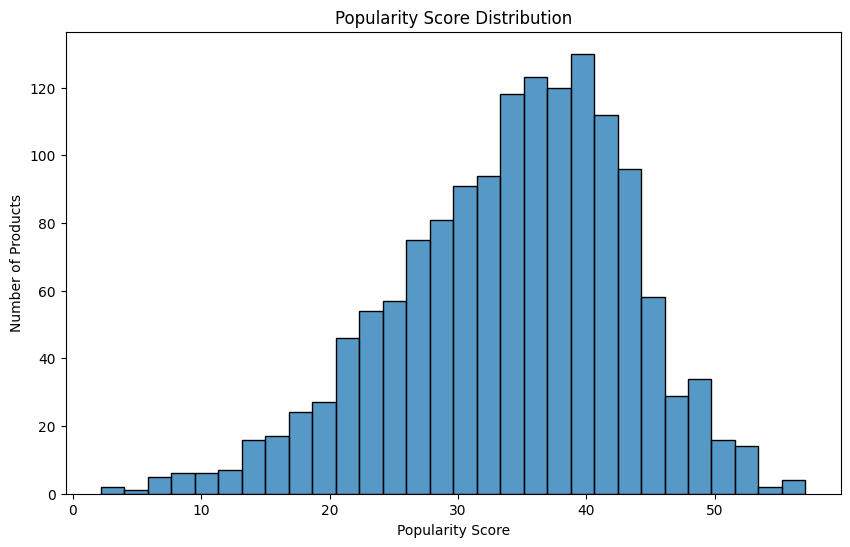

In [58]:
plt.figure(figsize=(10,6))

sns.histplot(
    cleaned_df['popularity_score'],
    bins=30
)

plt.title("Popularity Score Distribution")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Products")

plt.show()

In [55]:
cleaned_df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'discount_amount',
       'discount_ratio', 'popularity_score'],
      dtype='str')

In [56]:
cleaned_df.to_csv(
    "../data/cleaned_amazon.csv",
    index=False
)

In [57]:
import os

os.listdir("../data")

['amazon.csv', 'cleaned_amazon.csv']